In [1]:
import pandas as pd
from os import listdir, path
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%load_ext jupyter_capture_output

Jupyter Capture Output v0.0.11
The jupyter_capture_output module is not an IPython extension.


# Task 1
Assume we are running an A/B test on a difficulty flow, and each variant receives
exactly 20,000 installs per day. Write the codes to analyze and create graphics.

In [2]:
variant_a_given_data = {
    "dpr": 0.0305,
    "ecpm": 9.80,
    "imp_per_dau": 2.3,
    "d1_ret": 0.53,
    "d3_ret": 0.27,
    "d7_ret": 0.17,
    "d14_ret": 0.06,
}
variant_b_given_data = {
    "dpr": 0.0315,
    "ecpm": 10.80,
    "imp_per_dau": 1.6,
    "d1_ret": 0.48,
    "d3_ret": 0.25,
    "d7_ret": 0.19,
    "d14_ret": 0.09,

}
simulation_length = 120

### a) Which variant will have the **most daily active users** after 15 days?
For this part I will first interpolate the retentions and then take calculate DAU for each day according to this interpolation.

In [3]:
# Sample known retention data 
variant_a_data = {'day': [1, 3, 7, 14], 'retention': [
    variant_a_given_data["d1_ret"],
    variant_a_given_data["d3_ret"],
    variant_a_given_data["d7_ret"],
    variant_a_given_data["d14_ret"],
]}
variant_a_df_retention = pd.DataFrame(variant_a_data)
variant_b_data = {'day': [1, 3, 7, 14], 'retention': [
    variant_b_given_data["d1_ret"],
    variant_b_given_data["d3_ret"],
    variant_b_given_data["d7_ret"],
    variant_b_given_data["d14_ret"],
]}
variant_b_df_retention = pd.DataFrame(variant_b_data)

# Define Power Law function: R(n) = a * n^b 
# Source for the method https://www.linkedin.com/pulse/retention-curves-heuristic-approach-russell-ovans-f15qc
def power_law(n, a, b):
    return a * np.power(n, b)

# Fit the curve
popt_variant_a, pcov_variant_a = curve_fit(power_law, variant_a_df_retention['day'], variant_a_df_retention['retention'])
a_fit_variant_a, b_fit_variant_a = popt_variant_a

popt_variant_b, pcov_variant_b = curve_fit(power_law, variant_b_df_retention['day'], variant_b_df_retention['retention'])
a_fit_variant_b, b_fit_variant_b = popt_variant_b


# Predict retention for missing days (e.g., up to simulation_length0)
all_days = pd.DataFrame({'day': np.arange(1, simulation_length)})
all_days['predicted_retention_variant_a'] = power_law(all_days['day'], a_fit_variant_a, b_fit_variant_a)
all_days['predicted_retention_variant_b'] = power_law(all_days['day'], a_fit_variant_b, b_fit_variant_b)

Output saved by overwring previous file at img/task_1/ret_inter.png.


<Axes: xlabel='day'>

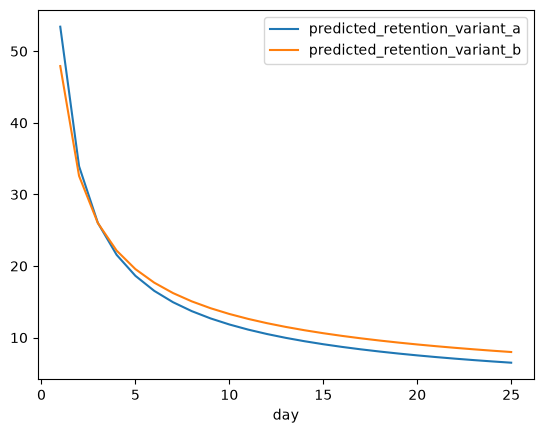

In [4]:
%%capture_img --path "./img/task_1/ret_inter.png"

(all_days.head(25).set_index("day")*100).plot()

In [5]:
daily_sim = pd.DataFrame({'day': np.arange(1, simulation_length)})
daily_sim['installs'] = 20000

daily_sim['dau_a'] = np.convolve(
    daily_sim['installs'],
    np.r_[1.0 , all_days['predicted_retention_variant_a']]
)[:len(daily_sim)].astype(int)

daily_sim['dau_b'] = np.convolve(
    daily_sim['installs'],
    np.r_[1.0 , all_days['predicted_retention_variant_b']]
)[:len(daily_sim)].astype(int)

daily_sim = daily_sim.set_index('day')

In [6]:
def value_diff_charts(daily_sim, a_field, b_field, diff_field, title):
    """
    diff_field must be B - A
    """
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )
    
    # Original DAU
    ax1.plot(daily_sim.index, daily_sim[a_field], label="A")
    ax1.plot(daily_sim.index, daily_sim[b_field], label="B")
    ax1.legend()
    ax1.set_ylabel(title)
    
    # Difference
    ax2.plot(daily_sim.index, daily_sim[diff_field], color="black")
    ax2.axhline(0, color="red", linestyle="--")
    ax2.fill_between(
        daily_sim.index,
        daily_sim[diff_field],
        0,
        where=daily_sim[diff_field] > 0,
        alpha=0.3,
        color="green"
    )
    ax2.fill_between(
        daily_sim.index,
        daily_sim[diff_field],
        0,
        where=daily_sim[diff_field] < 0,
        alpha=0.3,
        color="red"
    )
    
    ax2.set_ylabel("B - A")

Output saved by overwring previous file at img/task_1/dau.png.


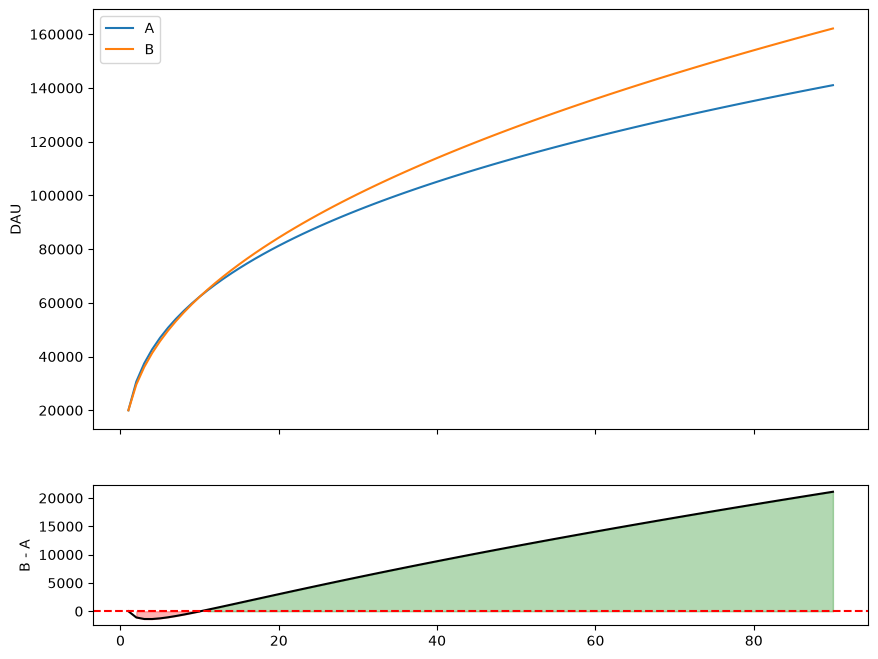

In [79]:
%%capture_img --path "./img/task_1/dau.png"

daily_sim["diff"] = daily_sim["dau_b"] - daily_sim["dau_a"]
value_diff_charts(daily_sim[:90], "dau_a", "dau_b", "diff", "DAU")

In [8]:
daily_sim[["dau_a", "dau_b"]].loc[15]

dau_a    72870
dau_b    74351
Name: 15, dtype: int64

According to above results Variant B will have more users than Variant B by the day 15.

### b) Which variant will earn the **most total money** by Day 15?
I will use the same DAU data from the previous part and calculate daily revenue by using other monetization metrics.

In [9]:
daily_sim["ecpm_a"] = variant_a_given_data["ecpm"]
daily_sim["imp_per_dau_a"] = variant_a_given_data["imp_per_dau"]
daily_sim["dpr_a"] = variant_a_given_data["dpr"]
daily_sim["ecpm_b"] = variant_b_given_data["ecpm"]
daily_sim["imp_per_dau_b"] = variant_b_given_data["imp_per_dau"]
daily_sim["dpr_b"] = variant_b_given_data["dpr"]

In [10]:
daily_sim["ad_rev_a"] = daily_sim["dau_a"] * daily_sim["imp_per_dau_a"] * daily_sim["ecpm_a"] / 1000
daily_sim["ad_rev_b"] = daily_sim["dau_b"] * daily_sim["imp_per_dau_b"] * daily_sim["ecpm_b"] / 1000
# I'm assuming dpr * dau gives IAP revenue
daily_sim["iap_rev_a"] = daily_sim["dau_a"] * daily_sim["dpr_a"]
daily_sim["iap_rev_b"] = daily_sim["dau_b"] * daily_sim["dpr_b"]

daily_sim["rev_a"] = daily_sim["ad_rev_a"] + daily_sim["iap_rev_a"]
daily_sim["rev_b"] = daily_sim["ad_rev_b"] + daily_sim["iap_rev_b"]
daily_sim["cumulative_rev_a"] = daily_sim["rev_a"].cumsum()
daily_sim["cumulative_rev_b"] = daily_sim["rev_b"].cumsum()

In [11]:
daily_sim.head()

,installs,dau_a,dau_b,diff,ecpm_a,imp_per_dau_a,dpr_a,ecpm_b,imp_per_dau_b,dpr_b,ad_rev_a,ad_rev_b,iap_rev_a,iap_rev_b,rev_a,rev_b,cumulative_rev_a,cumulative_rev_b
day,,,,,,,,,,,,,,,,,,
1,20000,20000,20000,0,9.8,2.3,0.0305,10.8,1.6,0.0315,450.80000,345.60000,610.0000,630.0000,1060.80000,975.60000,1060.80000,975.60000
2,20000,30685,29585,-1100,9.8,2.3,0.0305,10.8,1.6,0.0315,691.63990,511.22880,935.8925,931.9275,1627.53240,1443.15630,2688.33240,2418.75630
3,20000,37473,36103,-1370,9.8,2.3,0.0305,10.8,1.6,0.0315,844.64142,623.85984,1142.9265,1137.2445,1987.56792,1761.10434,4675.90032,4179.86064
4,20000,42678,41303,-1375,9.8,2.3,0.0305,10.8,1.6,0.0315,961.96212,713.71584,1301.6790,1301.0445,2263.64112,2014.76034,6939.54144,6194.62098
5,20000,46990,45733,-1257,9.8,2.3,0.0305,10.8,1.6,0.0315,1059.15460,790.26624,1433.1950,1440.5895,2492.34960,2230.85574,9431.89104,8425.47672


Output saved by overwring previous file at img/task_1/rev.png.


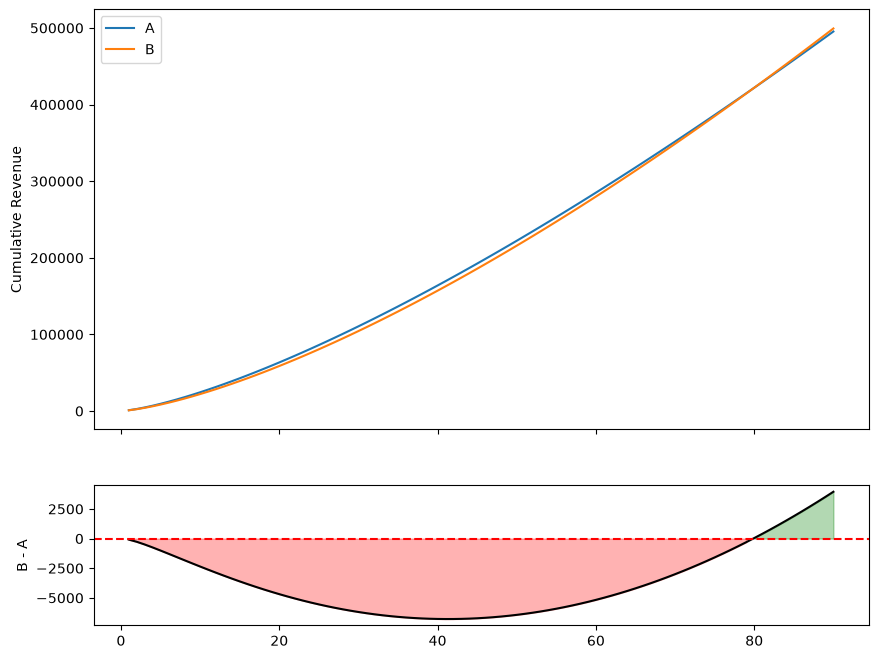

In [78]:
%%capture_img --path "./img/task_1/rev.png"

daily_sim["rev_diff"] = daily_sim["cumulative_rev_b"] - daily_sim["cumulative_rev_a"]
value_diff_charts(daily_sim[:90], "cumulative_rev_a", "cumulative_rev_b", "rev_diff", "Cumulative Revenue")

In [13]:
daily_sim[["cumulative_rev_a", "cumulative_rev_b"]].loc[15]

cumulative_rev_a    42748.27752
cumulative_rev_b    39140.19396
Name: 15, dtype: float64

Above results show Variant A earned more money by the test day 30.

### c) If we look at the **total money earned by Day 30** instead, does our choice change?


In [14]:
daily_sim[["cumulative_rev_a", "cumulative_rev_b"]].loc[30]

cumulative_rev_a    110571.05592
cumulative_rev_b    104381.59032
Name: 30, dtype: float64

No It doesn't change our choice, still Variant A has better monetization.

### d) What if we run a 10-day sale starting on Day 15 (boosting everyone's purchase rate by 1%)? Does this change which variant earns more **total money by Day 30**?

(I'm assuming Daily Purchase Ratios for Variant A goes from `0.0305` to `0.0405`. Not a 1% increase like `0.030805`)

In [15]:
daily_sim["dpr_a_sale"] = daily_sim["dpr_a"] 
daily_sim.loc[15:24 , "dpr_a_sale"] = daily_sim.loc[15:24]["dpr_a_sale"] + 0.01
daily_sim["dpr_b_sale"] = daily_sim["dpr_b"] 
daily_sim.loc[15:24 , "dpr_b_sale"] = daily_sim.loc[15:24]["dpr_b_sale"] + 0.01 
# I'm assuming dpr * dau gives IAP revenue
daily_sim["iap_rev_a_sale"] = daily_sim["dau_a"] * daily_sim["dpr_a_sale"]
daily_sim["iap_rev_b_sale"] = daily_sim["dau_b"] * daily_sim["dpr_b_sale"]
daily_sim["rev_a_sale"] = daily_sim["ad_rev_a"] + daily_sim["iap_rev_a_sale"]
daily_sim["rev_b_sale"] = daily_sim["ad_rev_b"] + daily_sim["iap_rev_b_sale"]
daily_sim["cumulative_rev_a_sale"] = daily_sim["rev_a_sale"].cumsum()
daily_sim["cumulative_rev_b_sale"] = daily_sim["rev_b_sale"].cumsum()
daily_sim.head()

,installs,dau_a,dau_b,diff,ecpm_a,imp_per_dau_a,dpr_a,ecpm_b,imp_per_dau_b,dpr_b,...,cumulative_rev_b,rev_diff,dpr_a_sale,dpr_b_sale,iap_rev_a_sale,iap_rev_b_sale,rev_a_sale,rev_b_sale,cumulative_rev_a_sale,cumulative_rev_b_sale
day,,,,,,,,,,,,,,,,,,,,,
1,20000,20000,20000,0,9.8,2.3,0.0305,10.8,1.6,0.0315,...,975.60000,-85.20000,0.0305,0.0315,610.0000,630.0000,1060.80000,975.60000,1060.80000,975.60000
2,20000,30685,29585,-1100,9.8,2.3,0.0305,10.8,1.6,0.0315,...,2418.75630,-269.57610,0.0305,0.0315,935.8925,931.9275,1627.53240,1443.15630,2688.33240,2418.75630
3,20000,37473,36103,-1370,9.8,2.3,0.0305,10.8,1.6,0.0315,...,4179.86064,-496.03968,0.0305,0.0315,1142.9265,1137.2445,1987.56792,1761.10434,4675.90032,4179.86064
4,20000,42678,41303,-1375,9.8,2.3,0.0305,10.8,1.6,0.0315,...,6194.62098,-744.92046,0.0305,0.0315,1301.6790,1301.0445,2263.64112,2014.76034,6939.54144,6194.62098
5,20000,46990,45733,-1257,9.8,2.3,0.0305,10.8,1.6,0.0315,...,8425.47672,-1006.41432,0.0305,0.0315,1433.1950,1440.5895,2492.34960,2230.85574,9431.89104,8425.47672


In [ ]:
daily_sim["rev_diff_sale"] = daily_sim["cumulative_rev_b_sale"] - daily_sim["cumulative_rev_a_sale"]


Output saved by creating file at img/task_1/rev_with_sale.png.


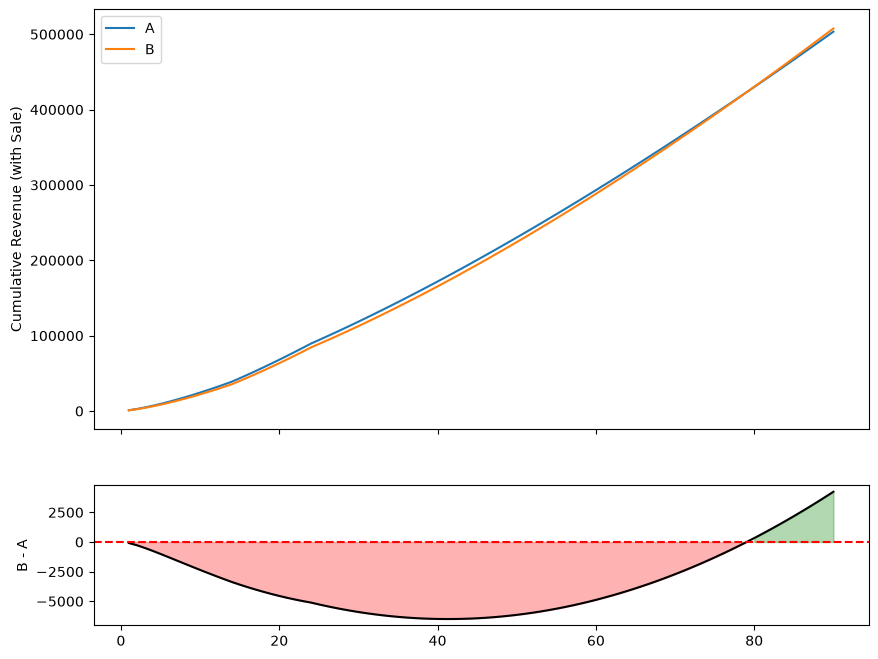

In [80]:
%%capture_img --path "./img/task_1/rev_with_sale.png"

daily_sim["rev_diff_sale"] = daily_sim["cumulative_rev_b_sale"] - daily_sim["cumulative_rev_a_sale"]
value_diff_charts(daily_sim[:90], "cumulative_rev_a_sale", "cumulative_rev_b_sale", "rev_diff_sale", "Cumulative Revenue (with Sale)")

In [81]:
daily_sim.loc[30, ["cumulative_rev_a_sale", "cumulative_rev_b_sale"]]

cumulative_rev_a_sale    118597.82592
cumulative_rev_b_sale    112694.44032
Name: 30, dtype: float64

This still doesn't change the result, Variant A is better.

### e) On Day 20 we add a new user source. From then on, we get 12,000 users from the original source and 8,000 from this new one. The new users' retention is described by these formulas. With this mix of old and new users, which variant makes more **total money by Day 30**?
● Variant A (New): $Retention = 0.58 \cdot e^{-0.12(x-1)}$

● Variant B (New): $Retention = 0.52 \cdot e^{-0.10(x-1)}$

In [84]:
def new_ret_func(day, base, power):
    return base*np.power(np.e, power*(day-1))

In [85]:

daily_sim["variant_a_new_source_retention"] = daily_sim.index.to_series().apply(new_ret_func, base=0.58, power=-0.12)
daily_sim["variant_b_new_source_retention"] = daily_sim.index.to_series().apply(new_ret_func, base=0.52, power=-0.10)
daily_sim["old_installs_a"] = 12000
daily_sim["old_installs_b"] = 12000
daily_sim["new_installs_a"] = 8000
daily_sim["new_installs_b"] = 8000
daily_sim.loc[:19,"old_installs_a"] = 20000
daily_sim.loc[:19,"old_installs_b"] = 20000
daily_sim.loc[:19,"new_installs_a"] = 0
daily_sim.loc[:19,"new_installs_b"] = 0

daily_sim['dau_a_combined_cohort'] = (
    np.convolve(
    daily_sim['old_installs_a'],
    np.r_[1.0 , all_days['predicted_retention_variant_a']]
)[:len(daily_sim)].astype(int)
+
    np.convolve(
    daily_sim['new_installs_a'],
    np.r_[1.0 , daily_sim["variant_a_new_source_retention"]]
)[:len(daily_sim)].astype(int)
)

daily_sim['dau_b_combined_cohort'] = (
    np.convolve(
    daily_sim['old_installs_b'],
    np.r_[1.0 , all_days['predicted_retention_variant_b']]
)[:len(daily_sim)].astype(int)
+
    np.convolve(
    daily_sim['new_installs_b'],
    np.r_[1.0 , daily_sim["variant_b_new_source_retention"]]
)[:len(daily_sim)].astype(int)
)

In [86]:
daily_sim["ad_rev_a_combined_cohort"] = daily_sim["dau_a_combined_cohort"] * daily_sim["imp_per_dau_a"] * daily_sim["ecpm_a"] / 1000
daily_sim["ad_rev_b_combined_cohort"] = daily_sim["dau_b_combined_cohort"] * daily_sim["imp_per_dau_b"] * daily_sim["ecpm_b"] / 1000
# I'm assuming dpr * dau gives IAP revenue
daily_sim["iap_rev_a_combined_cohort"] = daily_sim["dau_a_combined_cohort"] * daily_sim["dpr_a"]
daily_sim["iap_rev_b_combined_cohort"] = daily_sim["dau_b_combined_cohort"] * daily_sim["dpr_b"]

daily_sim["rev_a_combined_cohort"] = daily_sim["ad_rev_a_combined_cohort"] + daily_sim["iap_rev_a_combined_cohort"]
daily_sim["rev_b_combined_cohort"] = daily_sim["ad_rev_b_combined_cohort"] + daily_sim["iap_rev_b_combined_cohort"]
daily_sim["cumulative_rev_a_combined_cohort"] = daily_sim["rev_a_combined_cohort"].cumsum()
daily_sim["cumulative_rev_b_combined_cohort"] = daily_sim["rev_b_combined_cohort"].cumsum()

Output saved by overwring previous file at img/task_1/rev_with_new_cohort.png.


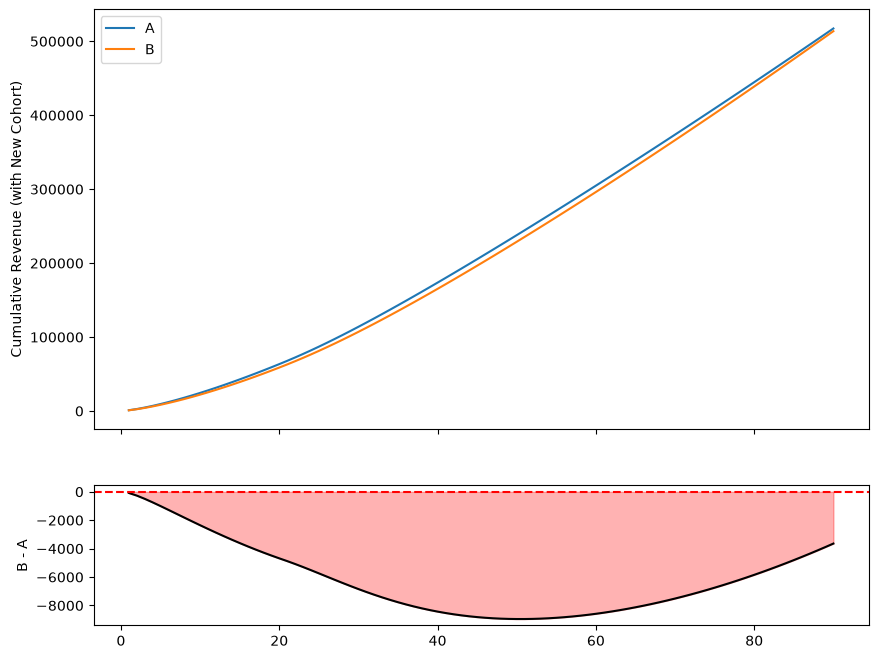

In [87]:
%%capture_img --path "./img/task_1/rev_with_new_cohort.png"

daily_sim["rev_diff_combined_cohort"] = daily_sim["cumulative_rev_b_combined_cohort"] - daily_sim["cumulative_rev_a_combined_cohort"]
value_diff_charts(daily_sim[:90], "cumulative_rev_a_combined_cohort", "cumulative_rev_b_combined_cohort", "rev_diff_combined_cohort", "Cumulative Revenue (with New Cohort)")

In [124]:
daily_sim.loc[30, ["cumulative_rev_a_sale", "cumulative_rev_b_sale", "cumulative_rev_a_combined_cohort", "cumulative_rev_b_combined_cohort"]]

cumulative_rev_a_sale               118597.82592
cumulative_rev_b_sale               112694.44032
cumulative_rev_a_combined_cohort    113908.12056
cumulative_rev_b_combined_cohort    107062.49034
Name: 30, dtype: float64

Still Variant A is the better one in terms of Day 30 Monetization.
### e) Which one should you prioritize, and why? If you could only make **one** of these improvements:
1. Run the temporary 10-day sale (from d)
2. Add the new, permanent user source (from e/f)


In [122]:
daily_sim.loc[[30, 60, 90, 119], ["cumulative_rev_a_sale", "cumulative_rev_b_sale", "cumulative_rev_a_combined_cohort", "cumulative_rev_b_combined_cohort"]].round(2)

,cumulative_rev_a_sale,cumulative_rev_b_sale,cumulative_rev_a_combined_cohort,cumulative_rev_b_combined_cohort
day,,,,
30,118597.83,112694.44,113908.12,107062.49
60,293097.68,288217.17,304792.13,296207.14
90,503419.73,507656.93,517348.08,513703.59
119,732537.79,752785.41,736610.98,742126.04


In [120]:
(all_days.loc[[30, 60, 90], ["predicted_retention_variant_a", "predicted_retention_variant_b"]] *100).round(2)

,predicted_retention_variant_a,predicted_retention_variant_b
30,5.64,7.09
60,3.62,4.86
90,2.79,3.89


In [121]:
(daily_sim.loc[[30, 60, 90], ["variant_a_new_source_retention", "variant_b_new_source_retention"]] *100).round(2)

,variant_a_new_source_retention,variant_b_new_source_retention
day,,
30,1.79,2.86
60,0.05,0.14
90,0.00,0.01


I would prefer the one time sale because in the long run new sources retentions are near 0. Day 60 and Day 90 retentions are showed above.